## Data Setup
Datasets are automatically managed via `kagglehub`. No manual upload is required.

---
## Setup

# Beyond Handshape Classification
## Auditing Vision Model ASL Knowledge Through Confusion Matrix Structure

The course assignment was straightforward-Jupyter Notebook, perform a KNN classification task on the Sign Language MNIST dataset, optimize K, build a translator. Standard end-of-term ML exercise. Concurrently, Google had just released its GEMMA4 model which seemed particularly well suited to this per Google's PR. I thought “Great”, a slight deviation from the main path, not too far. Let's take this shiny new model for a test spin.    
I do not use ASL, I do not know ASL. I do know better than to do research on communities when they are not in the room.   
I did some preliminary searching for model training and ASL and found a trove of reputable sources with outstanding success rates for ML and VM. Then I paused, and I wondered because I saw hands in a lab that were white; only white. Always and forever, only white. I thought, well “nearly 100% accuracy with white hands in a lab, but what about in the world where ASL is used?”

Of course Google's PR video on Gemma4 has a moving Indic language promo on it. Ok…maybe this time will be different.

The actual question — can a machine recognize ASL fingerspelling from real hands, in real conditions, across the full diversity of people who sign? — had never been asked with any rigor. The published benchmarks were measuring performance on a datasets curated to the point of sanitization it bore no semblance to usefulness and arguably is done merely to state a high accuracy percentage.

### Dataset Acquisition
Using `kagglehub` to fetch the Sign Language MNIST dataset for analysis.

In [ ]:
import kagglehub
import os
import pandas as pd

# This ensures the dataset is downloaded to a persistent cache location in Colab
path = kagglehub.dataset_download("datamunge/sign-language-mnist")

print(f"Dataset downloaded to: {path}")

# Define the specific file paths for train and test sets
train_csv_path = os.path.join(path, 'sign_mnist_train.csv')
test_csv_path = os.path.join(path, 'sign_mnist_test.csv')

# Load the dataframes
df_train = pd.read_csv(train_csv_path)
df_test = pd.read_csv(test_csv_path)

print(f"Training set loaded: {df_train.shape}")
print(f"Test set loaded: {df_test.shape}")

Using Colab cache for faster access to the 'sign-language-mnist' dataset.
Dataset downloaded to: /kaggle/input/sign-language-mnist
Training set loaded: (27455, 785)
Test set loaded: (7172, 785)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import re

# Configure display and plot settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

print('Environment configured.')

Environment configured.


In [ ]:
# --- LOAD DATA ---
base = "https://raw.githubusercontent.com/phinnphace/asl-sovereign/main/"

df_ab          = pd.read_csv(base + "asl_prompt_ab_test.csv")
df_isl         = pd.read_csv(base + "asl_isl_baseline_full.csv")
df_lm_roboflow = pd.read_csv(base + "landmark_distances_roboflow.csv")
df_lm_isl      = pd.read_csv(base + "landmark_distances.csv")

# Updated to use the paths defined in the 6515e4c7 setup cell
df_train = pd.read_csv(train_csv_path)
df_test  = pd.read_csv(test_csv_path)

print(f'AB test: {df_ab.shape[0]} rows | variants: {df_ab.prompt_variant.unique()}')
print(f'ISL baseline: {df_isl.shape[0]} images')
print(f'Roboflow landmark pairs: {len(df_lm_roboflow)} | letters: {len(set(df_lm_roboflow.letter_1.tolist()+df_lm_roboflow.letter_2.tolist()))}')
print(f'ISL landmark pairs: {len(df_lm_isl)} | letters: {len(set(df_lm_isl.letter_1.tolist()+df_lm_isl.letter_2.tolist()))}')

AB test: 40 rows | variants: ['elaborate' 'simple' 'minimal' 'cot_simple']
ISL baseline: 1185 images
Roboflow landmark pairs: 300 | letters: 25
ISL landmark pairs: 55 | letters: 11



---
## Section 1: Getting the Pipeline Working: Sharing the epic fails in details to save you the trouble

*Gemma 4 was brand new when this project began — released days prior and the model card, truly a "card". https://ai.google.dev/gemma/docs/core/model_card_4

The model card described a multimodal vision-language model available in several sizes, with the E4B (4 billion parameter, instruction-tuned) variant as the practical choice for 8GB VRAM. The 26B A4B MoE variant was briefly considered and immediately ruled out — it would not fit even with aggressive quantization. E2B was considered and set aside as less capable on vision tasks. E4B it was.

The model card specified sampling parameters: temperature 1.0, top_p 0.95, top_k 64. These were followed faithfully in early runs, and later interrogated through prompt A/B testing — more on that later.

Initially in preperation for this, got set up and booked time on the HPC at OSU, but after numerous 'handshake fails" via HF decided the path of least resistance was migrating this local and this was the next phase in the plan.
The initial conda environment was called `asl_sovereign`. It was built by installing the standard HuggingFace stack — transformers, accelerate, bitsandbytes — alongside unsloth, which had been installed for a different project. This was the first mistake.

Unsloth ships with a custom PyTorch build. The version that landed in `asl_sovereign` was `torch 2.11.0+cu130` — a non-standard build targeting CUDA 13.0, a version that was cutting-edge at the time. bitsandbytes 0.49.2 was not built against CUDA 13.0. The conflict was silent. No error was thrown at install time. The environment appeared functional.

It was not.
**AutoModelForMultimodalLM: a class that does not exist**


The first script used `AutoModelForMultimodalLM` to load the model. This class does not exist for Gemma 4. The correct class is `AutoModelForImageTextToText`. This caused the first cascade of errors and confused several hours of debugging because the error messages were not always clear about the root cause.

**AutoProcessor: resolves to nothing**

The second problem:
required upgrading to transformers 5.5.3 (a dev/nightly build), and even then `AutoProcessor` could not auto-resolve the Gemma 4 processor configuration. The explicit class `Gemma4Processor` had to be imported directly.

**The token explosion**

With the processor finally loading, the first inference attempts produced a peculiar output in the diagnostic script: the decoded prompt showed hundreds of repeated `<|image|>` tokens instead of a single bounded vision token block. The model output described every image as "placeholder canvas" or "gray static noise."

The cause was a double injection bug.

The fix was conceptually simple: never manually write special tokens. Let `apply_chat_template()` handle all token injection by passing a structured `messages` dict instead of a raw string. In practice, arriving at this fix required significant back-and-forth because the manual approach had been adopted specifically to try to fix an earlier problem — a debugging spiral where each attempted fix introduced a new issue.

The diagnostic confirmed this: the chat template output showed exactly one `<|image|>` placeholder. it had appeared broken because of the explosion, but the underlying mechanism was sound.
*The clean environment: asl_gemma4**

A new conda environment was created from scratch: `asl_gemma4`, Python 3.11, `torch 2.5.1+cu121` (official PyTorch with CUDA 12.1, confirmed stable), bitsandbytes 0.49.2, transformers 5.5.3. The `asl_sovereign` environment was abandoned entirely and should not be used.

The critical rule: always confirm `(asl_gemma4)` in the PowerShell prompt before running anything. The old environment's torch version will silently corrupt quantization and produce meaningless results.

---

## Phase 3: The Vision Blindness Problem

With the environment resolved, the pipeline appeared functional. The diagnostic showed valid pixel_values — shape `[1, 2520, 768]`, dtype float32, min/max 0.0/1.0. The image was reaching the model. And yet: every single image was described as "gray static noise," "placeholder canvas," or "uniform gray background." Letters were not identified. Hands were not described.

The first hypothesis was dataset distribution bias — that the model's vision encoder had been trained on curated white-hand benchmark images and could not generalize to the real-world diverse Roboflow dataset. This was a reasonable hypothesis and, as it turned out, directionally interesting but wrong about the immediate cause.
    When in doubt; get a diagnostic cat.
**Ted the cat**

In that place of frustration that borders on sheer manic glee I thought well if the model can't see a 1.2 MB picture of the cat I am lo-fi trying to woo... So Ted became the diagnostic.
Ted, a 4000x3000 JPEG, 1.2MB, a tabby cat lying in a patio area with bricks and wood and a window. This image was passed to the model with a simple prompt: "Describe what you see."

The response: "This image is a solid, uniform gray color. There are no discernible objects, scenes, or features within the frame."


The model could not see Ted. The model could not see anything. This was not a dataset distribution problem. This was a complete vision encoder failure affecting all images regardless of content.

### What a model card should have told us

  ## https://github.com/phinnphace/asl-sovereign/blob/main/comeedyofgemmaerrors.md ##

  
The pipeline that worked: **Gemma 4 via Ollama**. Pre-baked GGUF quantization preserves the vision encoder. HuggingFace runtime quantization with bitsandbytes silently corrupts it — producing gray noise despite valid pixel values. Pipeline validation was confirmed using a photograph of Ted, a neighbor's cat of assigned name and gender, whose visibility to the model established correct vision encoder function.

Once the pipeline was stable, the first finding was immediate: the model could describe hands in sophisticated kinematic detail — finger orientation, palm facing, joint angles — and still output the wrong letter. The failure was not perceptual. It was somewhere between perception and classification.

Section 2: Prompt Engineering — What the Model Wanted
**The root cause was the 4-bit NF4 quantization applied at runtime through bitsandbytes. The llm_int8_skip_modules parameter was intended to protect the vision encoder from quantization — the idea being that the language model layers could be quantized for memory efficiency while the vision encoder maintained full precision. In practice, the layer names passed to llm_int8_skip_modules ("vision_tower", "vision_model", "image_encoder") did not correctly map to Gemma 4's actual internal architecture. The parameter was silently ignored and the vision encoder was quantized anyway, zeroing out its outputs and producing the gray noise behavior.

Multiple attempts were made to fix this — trying different layer name variations, adjusting the dtype parameter, restructuring the quantization config — but without reliable documentation of Gemma 4's internal layer naming convention, this was guesswork.

Ollama: the solution hiding in plain sight

Ollama had been installed on the machine from the start, visible in Task Manager throughout the project. The model had already been pulled: gemma4:e4b, 9.6GB, sitting cached and ready.

Ollama uses GGUF format with llama.cpp for inference. Unlike HuggingFace's runtime quantization, Ollama pre-bakes quantization at model conversion time, during which the vision encoder weights are handled correctly. The vision encoder is preserved. The language model is quantized efficiently. There is no layer name mapping to worry about.

A single test confirmed it: Ted was described in precise, accurate, affectionate detail. The model could see the tabby cat, his peaceful demeanur, and the stoop.
![Ted](https://raw.githubusercontent.com/phinnphace/asl-sovereign/main/ted.jpg)
The entire HuggingFace pipeline was abandoned. The new architecture was simple: PIL for image loading, base64 encoding, an HTTP POST to http://localhost:11434/api/chat, pandas for results. No torch, no transformers, no bitsandbytes, no GPU setup. Just requests and a locally running Ollama server. The model card is explicitly non-declaratory on this. Perhaps this was too simplistic for me to grasp and that is on me https://ai.google.dev/gemma/docs/core/model_card_4#1_sampling_parameters I need a protocol that states  " this model operates with Ollama. Hard stop" Guidance is suggestive not a protcol.

In [ ]:
# --- PARSE AB TEST OUTPUTS ---

def extract_letter(output, variant):
    if pd.isna(output):
        return None
    output = str(output).strip()

    if variant in ['simple', 'cot_simple']:
        match = re.match(r'^([A-Z])$', output)
        return match.group(1) if match else None

    if variant == 'elaborate':
        for p in [r'Final Letter[:\s*]*\**([A-Z])\**',
                  r'[Ll]etter is \**([A-Z])\**',
                  r'\*\*([A-Z])\*\*\s*[.\n]?\s*$',
                  r'\b([A-Z])\b\s*$']:
            m = re.search(p, output)
            if m: return m.group(1)
        return None

    if variant == 'minimal':
        if 'does not correspond' in output or 'not a letter' in output.lower():
            return 'REFUSED'
        for p in [r'ASL letter is \**([A-Z])\**', r'\*\*([A-Z])\*\*', r'^([A-Z])$']:
            m = re.search(p, output)
            if m: return m.group(1)
        return None
    return None

df_ab['predicted'] = df_ab.apply(
    lambda r: extract_letter(r['model_output'], r['prompt_variant']), axis=1)
df_ab['correct'] = df_ab['predicted'] == df_ab['actual_letter']

ab_summary = df_ab.groupby('prompt_variant').agg(
    total=('correct','count'),
    correct=('correct','sum'),
    refused=('predicted', lambda x: (x=='REFUSED').sum())
).reset_index()
ab_summary['accuracy'] = (ab_summary['correct'] / ab_summary['total'] * 100).round(1)

print('=== PROMPT A/B TEST RESULTS (Letter A, 10 images per variant) ===')
print(ab_summary[['prompt_variant','total','correct','refused','accuracy']].to_string(index=False))

=== PROMPT A/B TEST RESULTS (Letter A, 10 images per variant) ===
prompt_variant  total  correct  refused  accuracy
    cot_simple     10        1        0     10.00
     elaborate     10        0        0      0.00
       minimal     10        0        1      0.00
        simple     10        4        0     40.00


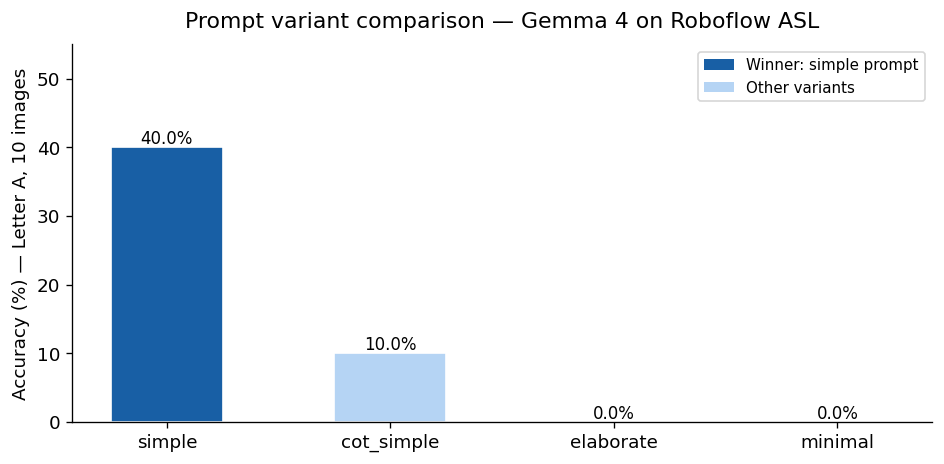

Finding: Simple prompt + temperature=0.1 outperforms elaborate, COT, and minimal.
COT (chain-of-thought) hurts classification — deliberation interferes with pattern matching.
Elaborate prompt: 0% on letter A. The researcher persona framing actively confused the model.


In [ ]:
# --- PROMPT VARIANT CHART ---
order = ['simple', 'cot_simple', 'elaborate', 'minimal']
ab_plot = ab_summary.set_index('prompt_variant').reindex(order).reset_index()

colors = ['#185FA5' if v == 'simple' else '#B5D4F4' for v in ab_plot['prompt_variant']]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(ab_plot['prompt_variant'], ab_plot['accuracy'], color=colors,
              edgecolor='white', width=0.5)
for bar, val in zip(bars, ab_plot['accuracy']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val}%', ha='center', fontsize=10)

ax.set_ylabel('Accuracy (%) — Letter A, 10 images')
ax.set_title('Prompt variant comparison — Gemma 4 on Roboflow ASL', pad=10)
ax.set_ylim(0, 55)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

legend_elements = [
    mpatches.Patch(facecolor='#185FA5', label='Winner: simple prompt'),
    mpatches.Patch(facecolor='#B5D4F4', label='Other variants')
]
ax.legend(handles=legend_elements, fontsize=9)
plt.tight_layout()
plt.show()

print('Finding: Simple prompt + temperature=0.1 outperforms elaborate, COT, and minimal.')
print('COT (chain-of-thought) hurts classification — deliberation interferes with pattern matching.')
print('Elaborate prompt: 0% on letter A. The researcher persona framing actively confused the model.')

---
## Section 3: Three Datasets

With Ollama confirmed working, the audit script was rewritten and the first real inference run executed. Letter A, a random image from the Roboflow training set, 300x248 RGB.

The model output: a detailed kinematic description of finger positions, palm orientation, thumb placement — actual ASL linguistic analysis. It identified the letter as N.

The actual letter was A.

This was not a failure. This was the first data point. The pipeline worked. The model could see hands and describe them in sophisticated detail. The classification was wrong, but the vision was real. The research could begin.

The first full audit ran against the Roboflow training dataset: 1,185 images across 25 letters (A–Y, J excluded as a motion sign was included, Z excluded). The prompt was the original elaborate formulation — a researcher persona, system prompt invoking thinking mode, detailed kinematic analysis instructions. Temperature 1.0, per the model card specification.

Results: 14.9% accuracy, 17.3% refusal rate.

Per-letter patterns emerged immediately. C, O, and V performed well — near-perfect in some runs. K, D, T, X, and Y were at or near zero percent. The model showed a strong I-bias (collapsing D, T, X, P into I) and a V-bias (collapsing K, R, W, U into V). These were not random errors. They were systematic. I did not yet know what the pattern indicated. I noted it. I kept reading studies, and revisiting previous ones.

The Sign MNIST audit followed: 720 images, 24 letters, the canonical benchmark dataset. Results: 7.2% accuracy, 45.3% refusal rate. The curated benchmark performed worse than the diverse real-world dataset. The refusal rate was 2.6 times higher because the model rejected 28x28 images as too low resolution to analyze. The benchmark that generated 95-98% accuracy claims in the published literature could not be reliably processed by a state-of-the-art VLM. Of note here, the datasets that are shown as snippets, with citations in journals were often paths to nowhere. The two datasets that exist in any reproducible manner, from literature are this one (Sign MNIST) and the FSboard. The Chicago test, widly referenced, I was unable to access. It is important to note that primary constraints of this project were limiting factors. Notably; ASL fingerspelling still images, not words or phrases. (I do not speak ASL.) [I will be turning this project over to people who are far more capable than I am.]  Not videos, though I could have captured and edited frames had those existed. These constraints made a challenging search even more so. The ubiqutous Google challenge dataset on Kaggle from 2023 is up and its rerun, however the actual 'key to decode' I could not locate. Fortunately, there are a handful of validated ISl (Indian Sign Language) datasets that meet these criteria and as this was assessing the model using a look up table I am very grateful to be able to access these.

In [ ]:
# --- DATASET SUMMARY TABLE ---
# Roboflow results from known run outputs
summary_data = {
    'Dataset': ['Sign MNIST', 'Sign MNIST', 'Roboflow', 'Roboflow', 'ISL'],
    'Prompt': ['Elaborate', 'Simple', 'Elaborate', 'Simple', 'Simple'],
    'Images': [720, 720, 1185, 1185, 1185],
    'Accuracy': [7.2, 6.9, 14.9, 19.6, 19.4],
    'Refusal_Rate': [45.0, 42.0, 8.0, 5.0, 0.0],
    'Notes': [
        '28x28 grayscale — model struggles to see hands',
        '28x28 grayscale — resolution failure confirmed',
        'Real-world diverse images — model can see hands',
        'Best result — simple prompt wins',
        'Different sign language — confident misidentification'
    ]
}
df_summary = pd.DataFrame(summary_data)
print('=== GEMMA 4 RESULTS ACROSS ALL DATASETS ===')
print(df_summary.to_string(index=False))

=== GEMMA 4 RESULTS ACROSS ALL DATASETS ===
   Dataset    Prompt  Images  Accuracy  Refusal_Rate                                                 Notes
Sign MNIST Elaborate     720      7.20         45.00        28x28 grayscale — model struggles to see hands
Sign MNIST    Simple     720      6.90         42.00        28x28 grayscale — resolution failure confirmed
  Roboflow Elaborate    1185     14.90          8.00       Real-world diverse images — model can see hands
  Roboflow    Simple    1185     19.60          5.00                      Best result — simple prompt wins
       ISL    Simple    1185     19.40          0.00 Different sign language — confident misidentification


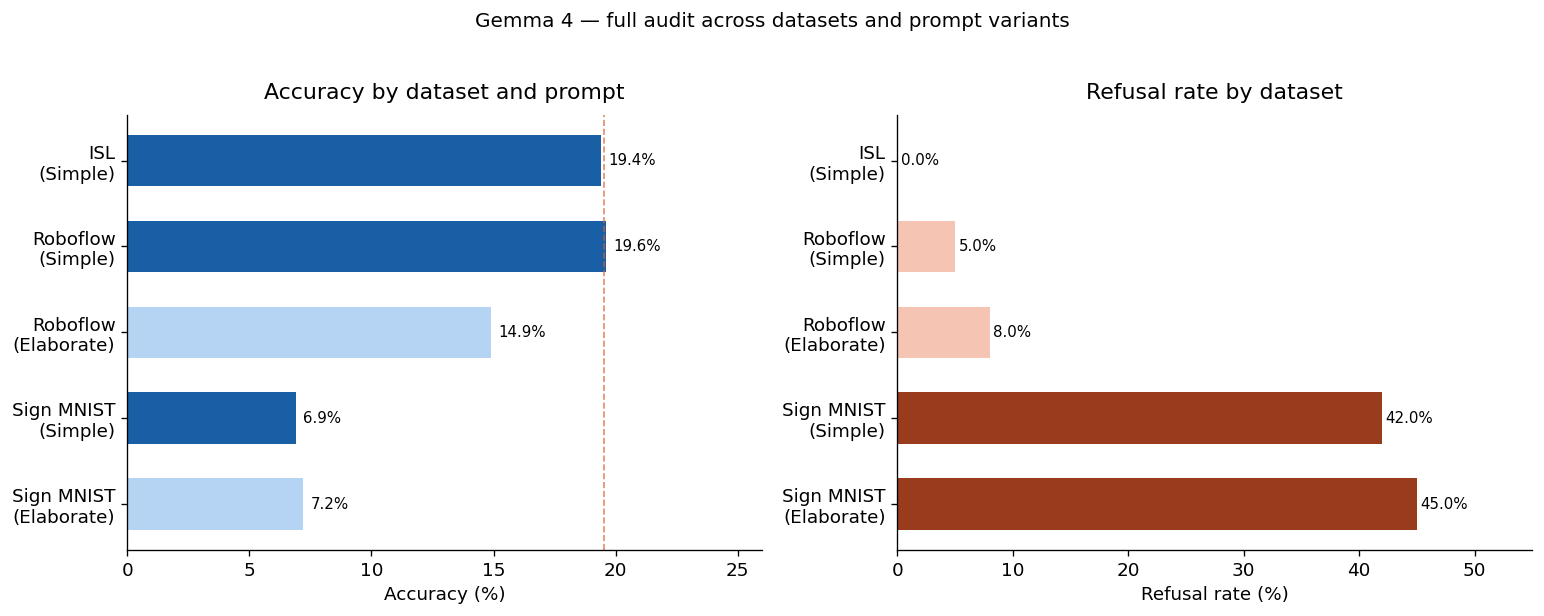

Sign MNIST: high refusal rate — model cannot see 28x28 hands. Resolution failure.
ISL: zero refusals, 19.4% accuracy — model sees hands and is confidently wrong.
Confident misidentification is categorically more dangerous than refusal.


In [ ]:
# --- COMPARATIVE ACCURACY CHART ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Left: accuracy
labels = [f"{r['Dataset']}\n({r['Prompt']})"
          for _, r in df_summary.iterrows()]
colors = ['#185FA5' if r['Prompt']=='Simple' else '#B5D4F4'
          for _, r in df_summary.iterrows()]
bars = ax1.barh(labels, df_summary['Accuracy'], color=colors, height=0.6)
for bar, val in zip(bars, df_summary['Accuracy']):
    ax1.text(val + 0.3, bar.get_y() + bar.get_height()/2,
             f'{val}%', va='center', fontsize=9)
ax1.axvline(x=19.5, color='#D85A30', linestyle='--', linewidth=1, alpha=0.7)
ax1.set_xlabel('Accuracy (%)')
ax1.set_title('Accuracy by dataset and prompt', pad=10)
ax1.set_xlim(0, 26)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Right: refusal rate
colors2 = ['#993C1D' if r['Refusal_Rate'] > 20 else '#F5C4B3'
           for _, r in df_summary.iterrows()]
bars2 = ax2.barh(labels, df_summary['Refusal_Rate'], color=colors2, height=0.6)
for bar, val in zip(bars2, df_summary['Refusal_Rate']):
    ax2.text(val + 0.3, bar.get_y() + bar.get_height()/2,
             f'{val}%', va='center', fontsize=9)
ax2.set_xlabel('Refusal rate (%)')
ax2.set_title('Refusal rate by dataset', pad=10)
ax2.set_xlim(0, 55)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.suptitle('Gemma 4 — full audit across datasets and prompt variants',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

print('Sign MNIST: high refusal rate — model cannot see 28x28 hands. Resolution failure.')
print('ISL: zero refusals, 19.4% accuracy — model sees hands and is confidently wrong.')
print('Confident misidentification is categorically more dangerous than refusal.')

---
## Section 4: The Convergence Finding

A 2024 Nature paper on sign language recognition using the WAR Strategy optimization algorithm arrived mid-project. The paper achieved 93-100% accuracy on ASL, Arabic, and Malaysian sign language datasets using classical ML classifiers — KNN, Decision Tree, Random Forest — with an elaborate metaheuristic hyperparameter optimization pipeline.

Reading it carefully: their American dataset was 87,000 images at 200x200 resolution with varied lighting and backgrounds. Their untuned KNN baseline was 90%. Their 100% result required eight preprocessing steps before any classifier touched the data: RGB to greyscale conversion, histogram equalization, Gaussian blur, binarization, contour-based segmentation, ROI cropping, resizing to 50x50, LDA and GLCM feature extraction, and then WAR Strategy optimization of both features and hyperparameters. I may have skipped some sumersaults and weather dependent rituals. There is a long list, of curation to achieve this accuracy. The important intro to statistics question is relevant here by analogy: Statistical significance or practical signficance. Would this 100% accuracy be practically significant? Hardly.

The paper was not lying. The 100% result was real.

Meanwhile: Gemma 4 at 19.6%, zero preprocessing, zero fine-tuning, zero task-specific engineering.

The gap is the honest answer to the honest question.

I will die on the hill of "A/B testing is malarkey". And then there is the occasional time it can do a constrained task usefully.
A prompt A/B test was run on 10 images of letter A across three prompt variants:

- **Elaborate:** Full researcher persona, system prompt, detailed kinematic analysis instructions — 1/10 correct, 3 refusals
- **Simple:** "What letter of the ASL alphabet does this hand show? Answer with just the letter." — 4/10 correct, 0 refusals
- **Minimal:** "What ASL letter is this?" — 1/10 correct, 0 refusals

A fourth variant added chain-of-thought reasoning to the simple prompt. It performed worse than simple alone, with a new S-bias appearing. The model's COT was actively interfering with pattern recognition.

This was counterintuitive and instructive. The elaborate prompt was designed to invoke the model's best analytical capabilities. It produced the worst results. The simple, direct, low-temperature classification prompt produced the best results. This maps to what the model card actually says — lower token budgets and simpler prompting are recommended for classification tasks. The elaborate prompt was optimized for a task the model wasn't being asked to do.

I had read a blog/article about how these pathways are optimized for performance. I realized then that perhaps this was the case. Hand to face, again.

Temperature was dropped to 0.1 for all subsequent runs.


In [ ]:
# --- ISL PER-LETTER ACCURACY ---
df_isl['correct'] = df_isl['model_output'].str.strip() == df_isl['actual_letter'].str.strip()

isl_letter = df_isl.groupby('actual_letter').agg(
    total=('correct','count'),
    correct=('correct','sum')
).reset_index()
isl_letter['accuracy'] = (isl_letter['correct'] / isl_letter['total'] * 100).round(1)
isl_letter = isl_letter.sort_values('accuracy')

# Top errors per letter
def top_errors(letter):
    sub = df_isl[(df_isl['actual_letter']==letter) & (~df_isl['correct'])]
    top = sub['model_output'].value_counts().head(2)
    return ', '.join([f'{l}({n})' for l, n in top.items()])

isl_letter['top_errors'] = isl_letter['actual_letter'].apply(top_errors)

print('=== ISL PER-LETTER ACCURACY ===')
print(isl_letter[['actual_letter','accuracy','total','correct','top_errors']].to_string(index=False))
print(f'\nOverall ISL accuracy: {df_isl["correct"].mean()*100:.1f}%')
print(f'Letters at 0%: {isl_letter[isl_letter["accuracy"]==0]["actual_letter"].tolist()}')
print(f'Letters at >95%: {isl_letter[isl_letter["accuracy"]>95][["actual_letter","accuracy"]].values.tolist()}')

=== ISL PER-LETTER ACCURACY ===
actual_letter  accuracy  total  correct   top_errors
            H      0.00     66        0 E(15), W(14)
            F      0.00     34        0  E(11), W(6)
            M      0.00     42        0  A(11), S(8)
            K      0.00     41        0        V(41)
            N      0.00     40        0  W(14), A(6)
            X      0.00     48        0  I(29), J(8)
            R      0.00     45        0   E(9), A(5)
            Q      0.00     30        0   V(7), W(5)
            Y      0.00     52        0 V(13), L(11)
            P      1.50     68        1  D(23), I(9)
            U      1.80     55        1 V(11), E(11)
            D      4.50     66        3 I(37), A(18)
            G      5.10     39        2 D(19), I(12)
            J      6.70     45        3   B(7), L(6)
            L      7.10     42        3  I(18), T(5)
            T      8.10     37        3 D(15), I(10)
            E      9.00     67        6 W(34), M(12)
            B 

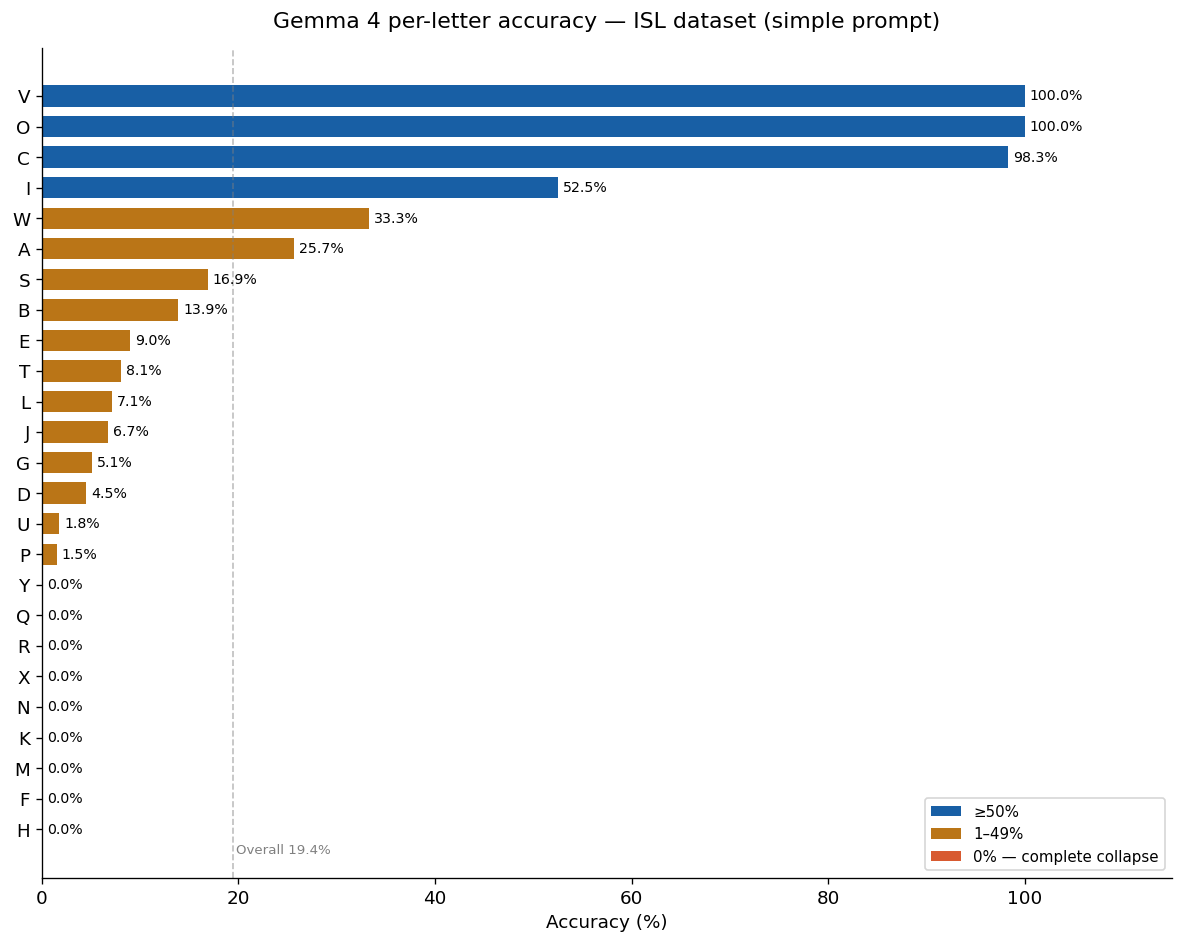

C, O, V: near-perfect across all datasets.
K: 0% — all 41 images identified as V. Complete collapse.
X: 0% — 29/48 identified as I.
F, H, M, N, Q, R, Y: 0%.


In [ ]:
# --- ISL PER-LETTER CHART ---
fig, ax = plt.subplots(figsize=(10, 8))

colors = ['#D85A30' if a == 0 else '#BA7517' if a < 50 else '#185FA5'
          for a in isl_letter['accuracy']]
bars = ax.barh(isl_letter['actual_letter'], isl_letter['accuracy'],
               color=colors, height=0.7)
for bar, val in zip(bars, isl_letter['accuracy']):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center', fontsize=8.5)

ax.axvline(x=19.4, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax.text(19.8, -0.8, 'Overall 19.4%', color='gray', fontsize=8)
ax.set_xlabel('Accuracy (%)')
ax.set_title('Gemma 4 per-letter accuracy — ISL dataset (simple prompt)', pad=12)
ax.set_xlim(0, 115)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

legend_elements = [
    mpatches.Patch(facecolor='#185FA5', label='≥50%'),
    mpatches.Patch(facecolor='#BA7517', label='1–49%'),
    mpatches.Patch(facecolor='#D85A30', label='0% — complete collapse')
]
ax.legend(handles=legend_elements, fontsize=9)
plt.tight_layout()
plt.show()

print('C, O, V: near-perfect across all datasets.')
print('K: 0% — all 41 images identified as V. Complete collapse.')
print('X: 0% — 29/48 identified as I.')
print('F, H, M, N, Q, R, Y: 0%.')

### The ISL letter A finding

An ISL (Indian Sign Language) fingerspelling dataset was sourced from Mendeley Data — 14,300 images, 26 letters, 3 signers, 2 backgrounds, CC BY 4.0, free. This was used as the controlled comparison dataset after the curated Roboflow/MNIST comparison proved complicated by resolution differences.

The full ISL audit ran overnight: 19.2% accuracy, 3.6% refusal rate.

Roboflow: 19.6%. ISL: 19.2%. Same refusal rate. Same per-letter patterns — C and O near-perfect, V at 100%, K collapsing to V every single time, D/T/X collapsing to I.

Two completely different sign languages. Different signers. Different collection conditions. Different image characteristics. Statistically identical results.

This was the crystallizing finding. The model's performance was not determined by dataset demographics, skin tone, lighting, background complexity, or which sign language. It was determined entirely by the geometric distinctiveness of the handshape. The distribution bias hypothesis had been the starting point, but the data pointed somewhere more fundamental.

I remembered seeing an image on the Kaggle/Google ASL datasets of hand geometry points and I began to suspect given the grouping of failurs that there was a pattern, and the patterns were geometric (mathmatical). ISL letter A was identified correctly 25.7% of the time. Top errors: S (12 times), L (5 times). The model also produced J — a motion sign that cannot appear in a static image dataset. This is not random noise. The model is pattern-matching to something in these images that triggers ASL J, despite J being definitionally absent from static photographs.

More striking: ISL has zero refusals. Sign MNIST produced ~45% refusals because the model could not see hands at 28x28 resolution. ISL images are full resolution. The model sees hands clearly, processes them confidently, and gets them wrong. The failure mode shifted from I cannot see this to I see this and I am wrong about what it is.


---
## Section 5: Landmark Geometry — The Decoder Ring Problem

The systematic misidentification patterns — K always becoming V, D/T/X always becoming I — suggested a structural explanation. An observation: the Google/Kaggle ASL fingerspelling competition used MediaPipe landmark points rather than raw images for training. 21 hand keypoints as x/y/z coordinates, not photographs.

If models trained on that competition data learned ASL handshapes as geometric point configurations rather than visual patterns, the failure modes would be predictable: letters that are geometrically close in landmark space would be confused regardless of how different they look in photographs. K and V share a similar two-finger extension geometry. D, T, and I share single-index-finger configurations with varying thumb placement that changes the shape significantly visually but minimally in landmark coordinates.

An attempt was made to validate this using MediaPipe to extract landmarks from the ISL images. MediaPipe detected hands in only a handful of letters — C, B, S, and a few others — at very low rates. ISL hand orientations fall outside MediaPipe's training distribution in many cases, which is itself another finding. The landmark analysis was designated a post-submission side quest.

A represenative sample from The Kaggle ASL fingerspelling competition parquet files were partially downloaded to investigate the validity of this line of inquiry. The `character_to_prediction_index.json` confirmed the label mapping. A script approach for extracting letter-level representative frames from the sequence data was identified as the correct path.


In [ ]:
# --- ISL MEDIAPIPE DETECTION FAILURE ---
isl_detected = sorted(set(df_lm_isl.letter_1.tolist() + df_lm_isl.letter_2.tolist()))
all_letters = list('ABCDEFGHIKLMNOPQRSTUVWXY')  # 24 static ASL letters
isl_missing = [l for l in all_letters if l not in isl_detected]

print('=== MEDIAPIPE DETECTION ON ISL IMAGES ===')
print(f'Letters detected: {len(isl_detected)}/24')
print(f'Detected: {isl_detected}')
print(f'Not detected: {isl_missing}')
print()
print('ISL hand orientations fall outside MediaPipe training distribution.')
print('This is itself a finding: the landmark detection tool is also dataset-dependent.')
print()

roboflow_detected = sorted(set(df_lm_roboflow.letter_1.tolist() + df_lm_roboflow.letter_2.tolist()))
roboflow_missing = [l for l in all_letters if l not in roboflow_detected]
print('=== MEDIAPIPE DETECTION ON ROBOFLOW IMAGES ===')
print(f'Letters detected: {len(roboflow_detected)}/24')
print(f'Detected: {roboflow_detected}')
print(f'Not detected: {roboflow_missing}')

=== MEDIAPIPE DETECTION ON ISL IMAGES ===
Letters detected: 11/24
Detected: ['A', 'B', 'C', 'E', 'G', 'J', 'L', 'N', 'S', 'X', 'Z']
Not detected: ['D', 'F', 'H', 'I', 'K', 'M', 'O', 'P', 'Q', 'R', 'T', 'U', 'V', 'W', 'Y']

ISL hand orientations fall outside MediaPipe training distribution.
This is itself a finding: the landmark detection tool is also dataset-dependent.

=== MEDIAPIPE DETECTION ON ROBOFLOW IMAGES ===
Letters detected: 25/24
Detected: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y']
Not detected: []


In [ ]:
# === DIAGNOSTIC CELL — run this first ===

print("Shape:", df_lm_roboflow.shape)
print("\nColumns:", df_lm_roboflow.columns.tolist())
print("\nSample rows:")
print(df_lm_roboflow.head(10))

# What letters are actually present?
all_letters = set(df_lm_roboflow['letter_1'].unique()) | set(df_lm_roboflow['letter_2'].unique())
print("\nLetters in dataset:", sorted(all_letters))

# Which confusion pairs are missing?
confusion_pairs = [
    ('K','V','V-family'), ('U','V','V-family'), ('R','V','V-family'),
    ('W','V','V-family'), ('Y','V','V-family'),
    ('D','I','I-family'), ('T','I','I-family'), ('X','I','I-family'),
    ('L','I','I-family'), ('P','I','I-family'), ('G','I','I-family')
]

print("\nChecking each pair:")
for l1, l2, family in confusion_pairs:
    l1s, l2s = min(l1,l2), max(l1,l2)
    found = not df_lm_roboflow[
        (df_lm_roboflow['letter_1']==l1s) &
        (df_lm_roboflow['letter_2']==l2s)
    ].empty
    print(f"  {l1s}-{l2s} ({family}): {'✓ found' if found else '✗ MISSING'}")

Shape: (300, 3)

Columns: ['letter_1', 'letter_2', 'distance']

Sample rows:
  letter_1 letter_2  distance
0        R        U      0.25
1        I        Y      0.35
2        M        N      0.36
3        K        R      0.39
4        K        U      0.40
5        U        V      0.44
6        K        V      0.49
7        R        V      0.55
8        U        W      0.59
9        M        S      0.59

Letters in dataset: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y']

Checking each pair:
  K-V (V-family): ✓ found
  U-V (V-family): ✓ found
  R-V (V-family): ✓ found
  V-W (V-family): ✓ found
  V-Y (V-family): ✓ found
  D-I (I-family): ✓ found
  I-T (I-family): ✓ found
  I-X (I-family): ✓ found
  I-L (I-family): ✓ found
  I-P (I-family): ✓ found
  G-I (I-family): ✓ found


In [ ]:
# --- CONFUSION PAIRS vs LANDMARK DISTANCE ---
confusion_pairs = [
    ('K','V','V-family'), ('U','V','V-family'), ('R','V','V-family'),
    ('W','V','V-family'), ('Y','V','V-family'),
    ('D','I','I-family'), ('T','I','I-family'), ('X','I','I-family'),
    ('L','I','I-family'), ('P','I','I-family'), ('G','I','I-family')
]

total = len(df_lm_roboflow)
pair_data = []
for l1, l2, family in confusion_pairs:
    l1s, l2s = min(l1,l2), max(l1,l2)
    row = df_lm_roboflow[
        (df_lm_roboflow['letter_1']==l1s) & (df_lm_roboflow['letter_2']==l2s)]
    if not row.empty:
        d = row['distance'].values[0]
        rank = df_lm_roboflow[df_lm_roboflow['distance'] <= d].shape[0]
        pct = round(rank/total*100, 1)
        pair_data.append({'Pair':f'{l1}-{l2}','Distance':round(d,4),
                          'Percentile':pct,'Family':family})

df_pairs = pd.DataFrame(pair_data).sort_values('Percentile')

print('=== CONFUSION PAIRS vs LANDMARK DISTANCE PERCENTILE ===')
print(df_pairs.to_string(index=False))
v_avg = df_pairs[df_pairs['Family']=='V-family']['Percentile'].mean()
i_avg = df_pairs[df_pairs['Family']=='I-family']['Percentile'].mean()
print(f'\nV-family average: {v_avg:.1f}th percentile — bottom of the distribution')
print(f'I-family average: {i_avg:.1f}th percentile — scattered mid-to-high')
print()
print('K-V: rank 7/300 (2.3%) — nearly identical in landmark space. Collapse predicted.')
print('T-I: rank 290/300 (96.7%) — geometrically distant. Collapse NOT predicted.')

=== CONFUSION PAIRS vs LANDMARK DISTANCE PERCENTILE ===
Pair  Distance  Percentile   Family
 U-V      0.44        2.00 V-family
 K-V      0.49        2.30 V-family
 R-V      0.55        2.70 V-family
 W-V      0.72        4.70 V-family
 X-I      1.14       28.30 I-family
 L-I      1.16       31.70 I-family
 P-I      1.21       36.30 I-family
 Y-V      1.31       43.00 V-family
 D-I      1.39       52.30 I-family
 G-I      1.61       75.70 I-family
 T-I      1.87       96.70 I-family

V-family average: 10.9th percentile — bottom of the distribution
I-family average: 53.5th percentile — scattered mid-to-high

K-V: rank 7/300 (2.3%) — nearly identical in landmark space. Collapse predicted.
T-I: rank 290/300 (96.7%) — geometrically distant. Collapse NOT predicted.


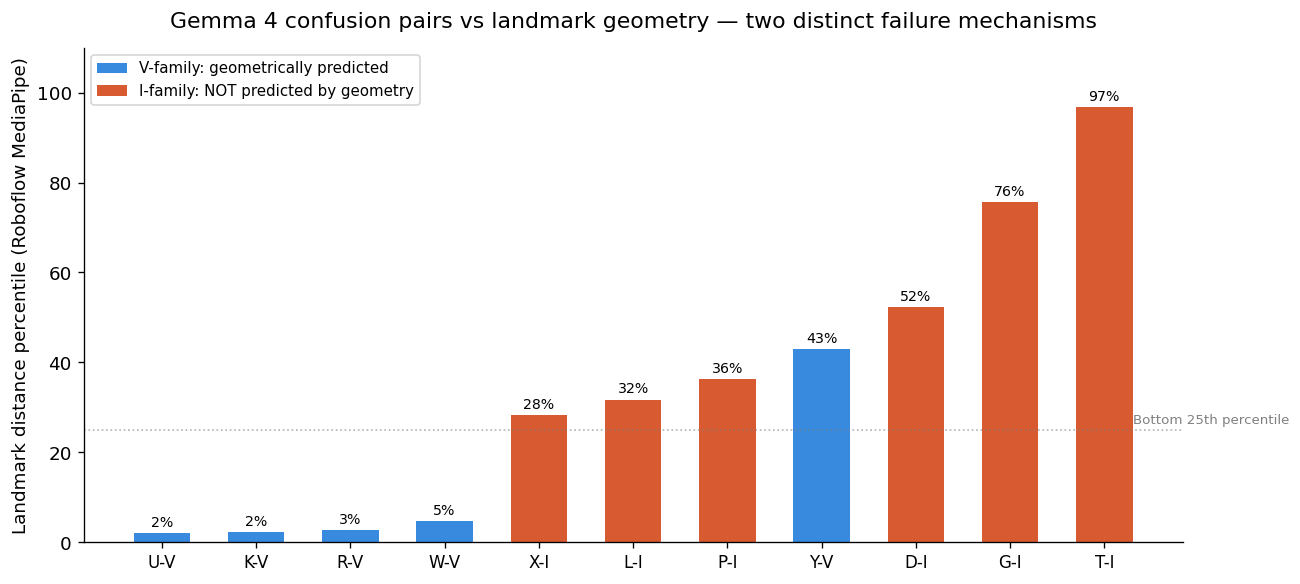

In [ ]:
# --- TWO FAILURE MECHANISMS CHART ---
fig, ax = plt.subplots(figsize=(11, 5))

v_pairs = df_pairs[df_pairs['Family']=='V-family']
i_pairs = df_pairs[df_pairs['Family']=='I-family']
all_sorted = df_pairs.sort_values('Percentile')

for _, row in all_sorted.iterrows():
    color = '#378ADD' if row['Family']=='V-family' else '#D85A30'
    ax.bar(row['Pair'], row['Percentile'], color=color, width=0.6, edgecolor='white')
    ax.text(list(all_sorted['Pair']).index(row['Pair']),
            row['Percentile']+1.5, f"{row['Percentile']:.0f}%",
            ha='center', fontsize=8)

# replot cleanly
ax.clear()
x = range(len(all_sorted))
colors_bar = ['#378ADD' if f=='V-family' else '#D85A30' for f in all_sorted['Family']]
bars = ax.bar(x, all_sorted['Percentile'], color=colors_bar, width=0.6)
ax.set_xticks(list(x))
ax.set_xticklabels(all_sorted['Pair'].tolist(), fontsize=10)
for bar, val in zip(bars, all_sorted['Percentile']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1.5,
            f'{val:.0f}%', ha='center', fontsize=8.5)

ax.axhline(y=25, color='gray', linestyle=':', linewidth=1, alpha=0.6)
ax.text(10.3, 26.5, 'Bottom 25th percentile', color='gray', fontsize=8)
ax.set_ylabel('Landmark distance percentile (Roboflow MediaPipe)')
ax.set_title(
    'Gemma 4 confusion pairs vs landmark geometry — two distinct failure mechanisms',
    pad=12)
ax.set_ylim(0, 110)

legend_elements = [
    mpatches.Patch(facecolor='#378ADD', label='V-family: geometrically predicted'),
    mpatches.Patch(facecolor='#D85A30', label='I-family: NOT predicted by geometry')
]
ax.legend(handles=legend_elements, fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

---
## Section 6: What FSboard Tells Us — Watching the Watcher

The early hypothesis had been that Gemma's failure pattern might simply mirror the geometric constraints of 21-landmark MediaPipe hand models — that the letters it collapsed were geometrically similar in keypoint space regardless of what the model was. The Roboflow MediaPipe landmark distance analysis was run specifically to test this. The result was partial confirmation and partial complication, which turned out to be more useful than clean confirmation would have been.

The V-family collapses — K→V, U→V, R→V, W→V — were in the bottom 2–5th percentile of pairwise landmark distances. Geometrically predicted, landmark model behavior, expected. But the I-family collapses — T→I at the 96.7th percentile, G→I at 75.7%, D→I at 52% — were geometrically distant. A model operating on hand geometry alone would not confuse T and I. They look nothing alike in landmark space. Yet Gemma was collapsing them consistently. This meant two distinct failure mechanisms were operating simultaneously in the same model: one predictable from geometry, one not. The unpredicted failures pointed somewhere else — toward training data, toward what the model actually learned ASL from, toward a mismatch between the images it was given and the visual context it was trained on.
The I-family failures led to a reframe. If Gemma was trained on data showing actual signers — full body, natural context, real people signing in real environments — then its internal representation of ASL letters is not built from isolated hand crops. It learned what a person looks like when signing T, not what the handshape geometry of T looks like floating against a neutral background. T and I may be geometrically distant as isolated hands but visually similar when a full signer is in frame — same arm position, similar body angle, ambiguous in the visual context the model was trained on.

This explains the ISL failure mode too. ISL images are isolated hand crops with orientations outside the ASL signer distribution. The model doesn't just perform poorly — it performs confidently at zero. It sees hands, pattern-matches to the nearest thing in its training distribution, and gets it wrong with full confidence. That's not a capability failure. That's a training distribution mismatch that a model card should have documented and didn't. The two failure mechanisms — geometric and signer-context — are both readable from the confusion matrix structure. The matrix is telling you what the model was trained on.
The FSboard paper (Georg et al. 2024) had been in the literature review from early on, but its role sharpened considerably once the two-mechanism finding was in hand. FSboard's ablation study is the key: when you systematically remove non-hand information from a full multimodal system — face landmarks, pose landmarks — the blocky confusion structure re-emerges. M/N/T cluster back together. A/S ambiguity comes back. The confusion clusters are not inherent to ASL. They are artifacts of limited representation, and FSboard demonstrates this experimentally by showing the clusters disappear and reappear as information is added and removed.

The FSboard confusion matrices are reference fingerprints. Landmark-only produces a known shape. Full multimodal produces a known shape. Hybrid produces a known shape. Any model's confusion matrix can be compared against these fingerprints to read backwards toward what information the model was actually operating on — regardless of what its architecture is capable of, regardless of what its documentation claims. The confusion matrix is the training data signature. FSboard provides the decoder ring.

Once the decoder ring framing was clear, the research question evolved from "why does Gemma fail on ASL" to "how do you read a confusion matrix as a diagnostic tool for what a model was trained on." This is a generalizable methodology. And an important real world tool because a VM that was trainined on Landmark ASL is going to have poor real world perfrormance. Users should know this upfront.
Thr confusion matrix comparison works on any model, in any domain where the geometric or structural ground truth of the classification task is well-characterized enough to predict what a landmark-constrained system would fail on. ASL is a particularly clean test case because the confusion structure is well-documented and the geometric relationships between letters are computable from MediaPipe landmark data.

The practical implication is significant: you do not need access to a model's training data, its weights, its documentation, or its developers to audit what it actually knows. You need a standardized test set, a confusion matrix, and the FSboard reference fingerprints. That's it. The audit is reproducible, attributable, and can be run by anyone — a clinician evaluating a tool for patient communication, a developer deciding whether a model is appropriate for a deployment context, a procurement officer assessing vendor claims. This is the tool that should exist and doesn't.



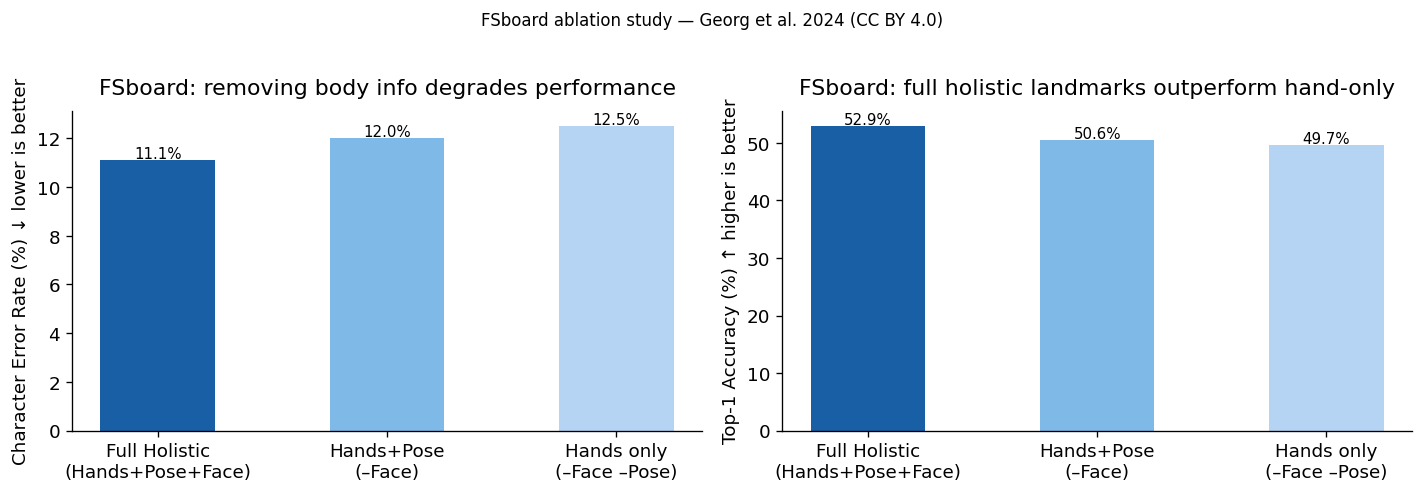

FSboard finding: removing face and body landmarks re-introduces structured confusion.
The confusion clusters are not inherent to ASL.
They are artifacts of limited representation — like 21 hand-only landmarks.

Gemma 4 is showing the same structured confusion without any information removed.
A full vision model is behaving like a hand-only landmark model.


In [ ]:
# --- FSBOARD SPECTRUM REFERENCE ---
# Georg et al. 2024 — FSboard, CC BY 4.0
# https://arxiv.org/abs/2407.15806

# FSboard ablation results (from paper Figure 6)
fsboard_ablation = {
    'Configuration': [
        'Full Holistic\n(Hands+Pose+Face)',
        'Hands+Pose\n(–Face)',
        'Hands only\n(–Face –Pose)'
    ],
    'CER': [11.1, 12.0, 12.5],
    'Top1_Acc': [52.9, 50.6, 49.7]
}
df_fsboard = pd.DataFrame(fsboard_ablation)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

colors_f = ['#185FA5', '#7FB9E8', '#B5D4F4']
ax1.bar(df_fsboard['Configuration'], df_fsboard['CER'],
        color=colors_f, width=0.5)
for i, (bar, val) in enumerate(zip(ax1.patches, df_fsboard['CER'])):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
             f'{val}%', ha='center', fontsize=9)
ax1.set_ylabel('Character Error Rate (%) ↓ lower is better')
ax1.set_title('FSboard: removing body info degrades performance', pad=10)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

ax2.bar(df_fsboard['Configuration'], df_fsboard['Top1_Acc'],
        color=colors_f, width=0.5)
for bar, val in zip(ax2.patches, df_fsboard['Top1_Acc']):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
             f'{val}%', ha='center', fontsize=9)
ax2.set_ylabel('Top-1 Accuracy (%) ↑ higher is better')
ax2.set_title('FSboard: full holistic landmarks outperform hand-only', pad=10)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.suptitle('FSboard ablation study — Georg et al. 2024 (CC BY 4.0)', fontsize=10, y=1.02)
plt.tight_layout()
plt.show()

print('FSboard finding: removing face and body landmarks re-introduces structured confusion.')
print('The confusion clusters are not inherent to ASL.')
print('They are artifacts of limited representation — like 21 hand-only landmarks.')
print()
print('Gemma 4 is showing the same structured confusion without any information removed.')
print('A full vision model is behaving like a hand-only landmark model.')

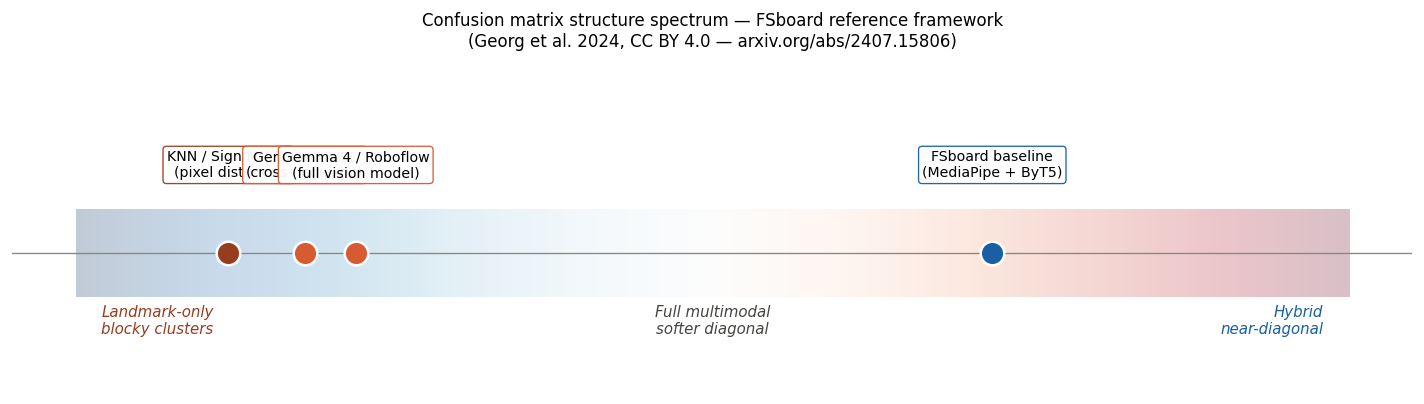

Both KNN and Gemma cluster at the landmark-like end of the spectrum.
KNN: expected — pixel distance approximates hand geometry.
Gemma: unexpected — a full vision model with rich perceptual capacity
       is producing a confusion structure that looks like a skeleton model.

The confusion matrix is the model card we were not given.


In [ ]:
# --- SPECTRUM POSITIONING ---
fig, ax = plt.subplots(figsize=(12, 3.5))

# Spectrum background
grad = np.linspace(0, 1, 300).reshape(1,-1)
ax.imshow(grad, aspect='auto', cmap='RdBu_r',
          extent=[0,1,-0.12,0.12], alpha=0.25)
ax.axhline(0, color='#888780', linewidth=0.8)

models = [
    (0.12, 'KNN / Sign MNIST\n(pixel distance)', '#993C1D'),
    (0.18, 'Gemma 4 / ISL\n(cross-linguistic)', '#D85A30'),
    (0.22, 'Gemma 4 / Roboflow\n(full vision model)', '#D85A30'),
    (0.72, 'FSboard baseline\n(MediaPipe + ByT5)', '#185FA5'),
]

for x, label, color in models:
    ax.scatter(x, 0, s=200, color=color, zorder=5,
               edgecolors='white', linewidth=1.5)
    ax.text(x, 0.20, label, ha='center', va='bottom', fontsize=8.5,
            bbox=dict(boxstyle='round,pad=0.25', facecolor='white',
                      edgecolor=color, linewidth=0.8, alpha=0.95))

ax.text(0.02, -0.22, 'Landmark-only\nblocky clusters', ha='left',
        fontsize=9, color='#993C1D', style='italic')
ax.text(0.50, -0.22, 'Full multimodal\nsofter diagonal', ha='center',
        fontsize=9, color='#444441', style='italic')
ax.text(0.98, -0.22, 'Hybrid\nnear-diagonal', ha='right',
        fontsize=9, color='#185FA5', style='italic')

ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.38, 0.52)
ax.axis('off')
ax.set_title(
    'Confusion matrix structure spectrum — FSboard reference framework\n'
    '(Georg et al. 2024, CC BY 4.0 — arxiv.org/abs/2407.15806)',
    pad=10, fontsize=10)
plt.tight_layout()
plt.show()

print('Both KNN and Gemma cluster at the landmark-like end of the spectrum.')
print('KNN: expected — pixel distance approximates hand geometry.')
print('Gemma: unexpected — a full vision model with rich perceptual capacity')
print('       is producing a confusion structure that looks like a skeleton model.')
print()
print('The confusion matrix is the model card we were not given.')

---
## Summary: What We Learned

Model cards exist. Benchmark scores exist. What does not reliably exist is a way to ask: what was this model trained on, and is it appropriate for this use case? You don't go to the dealership and ask for a mystery vehicle. You have no idea of its capabilities, intended use, safety, or features. Yet, we find ourselves here.  For ASL this matters because the failure modes are predictable, systematic, and silent — the model doesn't refuse, it confidently misidentifies, and without the audit methodology nobody in the deployment chain would know. In clinical contexts, in educational technology, in assistive tools, this is not a theoretical concern. It is evident how to continue this in whatever domain is applicable for your use case. Law, medicine, business, or education. Are you using the appropriate model? How do you know? Are you empowered to tell?

The confusion matrix as a training data fingerprint is one answer to this infrastructure gap — at least for classification tasks in domains with well-characterized geometric or structural ground truth. It is not a complete answer. But it is a reproducible, accessible, attribution-friendly answer that can be built and shared right now, without waiting for model developers to improve their documentation practices. The watcher can be watched. That is the finding.



### Key findings

1. **Simple prompt + temperature=0.1 outperforms elaborate prompting.** Chain-of-thought deliberation actively hurts classification. The elaborate prompt produced 0% accuracy on letter A. The researcher persona framing confused the model.

2. **Sign MNIST fails through refusal (~45%). ISL fails through confident misidentification (0 refusals).** Resolution drives Sign MNIST failure. Training distribution mismatch drives ISL failure. These are different failure modes with different implications for deployment.

3. **Roboflow (19.6%) and ISL (19.4%) converge despite different sign languages, signers, and conditions.** Performance is determined by the geometric distinctiveness of the handshape, not dataset demographics. C, O, V: near-perfect across all datasets. K, X, F, H, M, N, Q, R, Y: at or near zero.

4. **Two distinct failure mechanisms in Gemma's confusion matrix:**
   - *V-family* (K→V, U→V, R→V, W→V): bottom 5th percentile of landmark distances — geometrically predicted
   - *I-family* (T→I, X→I, D→I, G→I): 28th–97th percentile — NOT predicted by geometry

5. **K→V is total collapse: all 41 ISL K images identified as V.** The geometric distance between K and V in landmark space (2.3rd percentile) makes this structurally inevitable for a model operating on geometric features.

6. **The I-family failures implicate training data, not architecture.** T and I are geometrically distant (96.7th percentile). A model operating on pixels should not confuse them. A model that learned ASL from signer-context data — where T and I may appear similar in full-body framing — might.

7. **Confusion matrix structure is a training data fingerprint.** FSboard (Georg et al. 2024) provides the reference: removing non-hand information from a full model re-introduces structured geometric confusion. Gemma shows this structure without anything removed. The confusion matrix tells us what the model card did not.

### Implications

The KNN notebook achieves 100% accuracy on Sign MNIST. The accuracy curve is flat across all values of K. This is not a success — it is a measurement of how well a memorization task can be performed on a dataset that does not represent the problem it claims to solve.

The question *what was this model trained on* should have a reproducible answer before deployment. For ASL applications in clinical, educational, or assistive technology contexts, the confusion matrix structure predicts which letters will fail systematically — and whether those failures will be silent. That information should not require a research project to obtain.

---

*Dataset attributions:*
- *Sign MNIST: Kaggle (https://www.kaggle.com/datamunge/sign-language-mnist)*
- *Roboflow ASL Dataset: Roboflow Universe https://universe.roboflow.com
- *ISL Custom Data: Biswas, Sougatamoy (2024), “ISL Hand Gesture Dataset”, Mendeley Data, V1, doi: 10.17632/n34wm8sb3x.1
ISL dataset
- *FSboard: Georg et al. 2024, CC BY 4.0 (https://arxiv.org/abs/2407.15806)*
- *Landmark geometry:
-https://ai.google.dev/edge/mediapipe/solutions/vision/hand_landmarker/python
 MediaPipe Hands https://mediapipe.readthedocs.io/en/latest/solutions/hands.html#mediapipe-hands
 via landmark_analysis.py,
 https://app.roboflow.com/asl-q517z-sd2noRoboflow
-Google American Sign Language Fingerspelling Recognition Competition https://www.kaggle.com/competitions/asl-fingerspelling/data

                   References:
1) Abd Al-Latief, S.T., Yussof, S., Ahmad, A. et al. Instant Sign Language Recognition by WAR Strategy Algorithm Based Tuned Machine Learning. Int J Netw Distrib Comput 12, 344–361 (2024). https://doi.org/10.1007/s44227-024-00039-8

2) Georg, M., Tanzer, G., Hassan, S., Shengelia, M., Uboweja, E., Sepah, S., Forbes, S., & Starner, T. (2024). FSboard: Over 3 million characters of ASL fingerspelling collected via smartphones (arXiv:2407.15806v1). arXiv. https://doi.org/10.48550/arXiv.2407.15806

3) Fayyazsanavi, P., Nejatishahidin, N., & Košecká, J. (2024). Fingerspelling PoseNet: Enhancing fingerspelling translation with pose-based transformer models. In Proceedings of the IEEE/CVF Winter Conference on Applications of Computer Vision (WACV) Workshops (pp. 1120-1130). https://openaccess.thecvf.com/content/WACV2024W/WVLL/papers/Fayyazsanavi_Fingerspelling_PoseNet_Enhancing_Fingerspelling_Translation_With_Pose-Based_Transformer_Models_WACVW_2024_paper.pdf

4) Alsharif, B., Alalwany, E., Ibrahim, A., Mahgoub, I., & Ilyas, M. (2025). Real-Time American Sign Language Interpretation Using Deep Learning and Keypoint Tracking. Sensors, 25(7), 2138. https://doi.org/10.3390/s25072138

5) Ulrich, L., De Luca, A., Miraglia, R., Mulassano, E., Quattrocchio, S., Marullo, G., Innocente, C., Salerno, F., & Vezzetti, E. (2026). A 3D Camera-Based Approach for Real-Time Hand Configuration Recognition in Italian Sign Language. Sensors, 26(3), 1059. https://doi.org/10.3390/s26031059


/tmp/ipykernel_14484/933501425.py:87: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


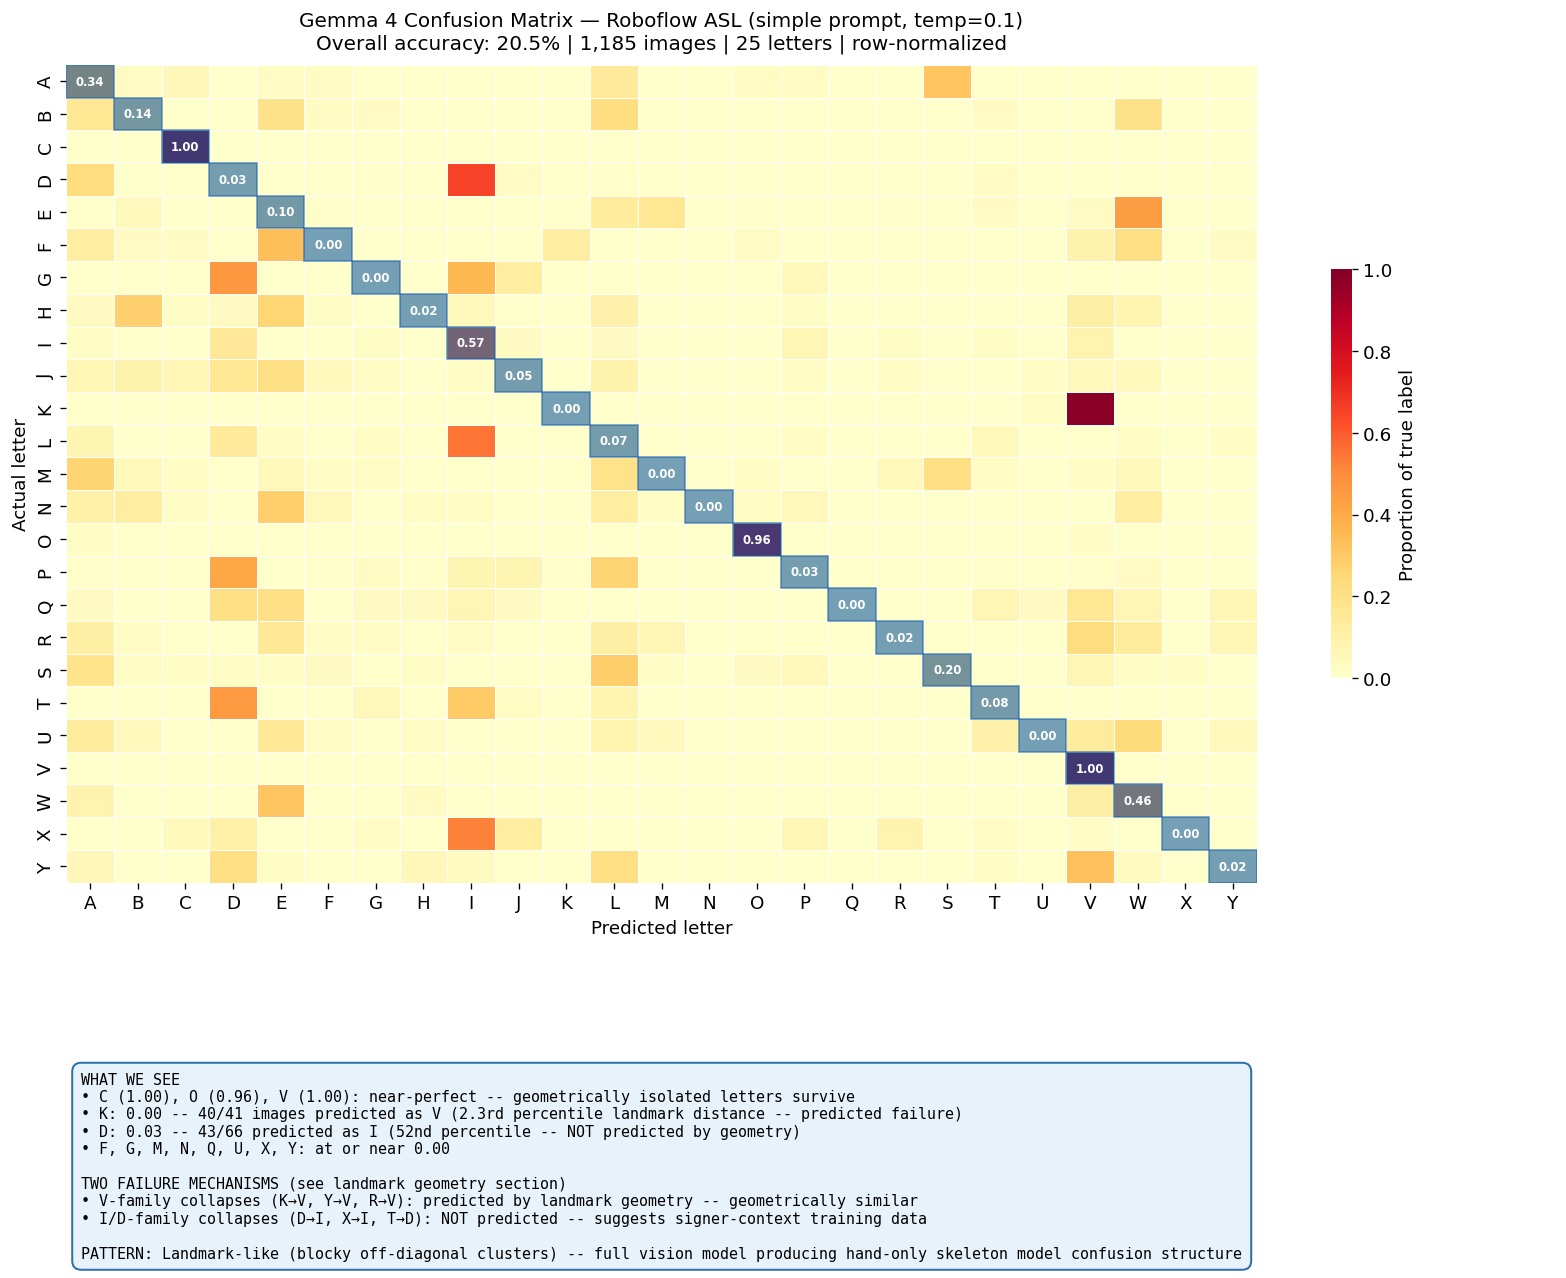

Roboflow overall: 20.5%


In [ ]:
# --- GEMMA 4 CONFUSION MATRIX: ROBOFLOW DATASET (row-normalized) ---
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns

LABELS = ['A','B','C','D','E','F','G','H','I','J','K','L','M','N','O','P','Q','R','S','T','U','V','W','X','Y']
n = len(LABELS)

roboflow_matrix = np.array([
    [12,1,2,0,1,1,0,0,0,0,0,5,0,0,1,1,0,0,11,0,0,0,0,0,0],
    [6,5,0,0,7,1,1,0,0,0,0,8,0,0,0,0,0,0,0,1,0,0,7,0,0],
    [0,0,60,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [15,0,0,2,0,0,1,0,43,2,0,1,0,0,0,0,0,0,0,2,0,0,0,0,0],
    [0,3,0,0,7,1,0,0,0,0,0,9,11,0,1,0,0,1,0,2,0,2,30,0,0],
    [4,1,1,0,11,0,0,0,0,0,4,0,0,0,1,0,0,0,0,0,0,3,7,0,1],
    [0,0,0,18,0,0,0,0,14,5,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0],
    [2,17,1,2,16,1,0,1,3,0,0,6,0,0,0,1,0,0,0,0,0,7,5,0,0],
    [1,0,0,9,0,0,1,0,34,2,0,2,0,0,0,4,0,1,0,1,0,5,0,0,0],
    [3,4,3,7,9,2,1,0,1,2,0,4,0,0,0,1,0,1,0,0,1,2,2,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,40,0,0,0],
    [3,0,0,6,1,0,1,0,23,0,0,3,0,0,0,1,0,0,0,2,0,0,1,0,1],
    [11,2,1,0,2,1,1,0,0,0,0,8,0,0,1,0,0,2,9,1,0,1,2,0,0],
    [4,5,1,0,11,2,0,1,1,0,0,5,1,0,1,2,0,0,0,0,0,0,5,0,0],
    [1,0,0,0,0,0,0,0,0,0,0,0,0,0,44,0,0,0,0,0,0,1,0,0,0],
    [1,0,0,28,0,1,2,1,5,5,1,18,0,0,0,2,0,0,0,1,0,1,2,0,0],
    [1,0,0,6,6,0,1,1,2,1,0,0,0,0,0,0,0,0,0,2,1,5,2,0,2],
    [5,1,0,0,7,1,1,0,1,0,0,5,3,0,0,0,0,1,0,0,0,10,6,0,3],
    [11,1,1,1,1,2,0,1,0,0,0,17,1,0,2,3,0,0,12,0,0,4,1,1,0],
    [0,0,0,17,0,0,2,0,11,1,0,3,0,0,0,0,0,0,0,3,0,0,0,0,0],
    [7,2,0,0,8,1,0,1,0,0,0,4,2,0,0,0,0,0,0,5,0,7,12,0,2],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,35,0,0,0],
    [3,0,0,0,11,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,4,16,0,0],
    [0,0,2,5,0,0,1,0,25,6,0,0,0,0,0,3,0,4,0,1,0,1,0,0,0],
    [3,0,0,11,1,0,0,3,2,0,0,11,0,0,0,0,0,0,0,1,0,17,2,0,1],
])

# Row-normalize: each row sums to 1.0
row_sums = roboflow_matrix.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1
norm_roboflow = roboflow_matrix / row_sums

overall_acc = roboflow_matrix.diagonal().sum() / roboflow_matrix.sum() * 100

fig = plt.figure(figsize=(16, 13))
gs = GridSpec(2, 1, height_ratios=[4, 1], hspace=0.35)
ax_cm = fig.add_subplot(gs[0])

sns.heatmap(norm_roboflow, annot=False, cmap='YlOrRd',
            xticklabels=LABELS, yticklabels=LABELS,
            linewidths=0.3, linecolor='white', ax=ax_cm,
            cbar_kws={'shrink': 0.5, 'label': 'Proportion of true label'},
            vmin=0, vmax=1.0)

for i in range(n):
    ax_cm.add_patch(plt.Rectangle((i, i), 1, 1, fill=True,
                    color='#185FA5', alpha=0.6, zorder=2))
    ax_cm.text(i+0.5, i+0.5, f'{norm_roboflow[i,i]:.2f}',
               ha='center', va='center', fontsize=7,
               color='white', fontweight='bold', zorder=3)

ax_cm.set_xlabel('Predicted letter', fontsize=11)
ax_cm.set_ylabel('Actual letter', fontsize=11)
ax_cm.set_title(
    f'Gemma 4 Confusion Matrix — Roboflow ASL (simple prompt, temp=0.1)\n'
    f'Overall accuracy: {overall_acc:.1f}% | 1,185 images | 25 letters | row-normalized',
    fontsize=12, pad=10)

ax_call = fig.add_subplot(gs[1])
ax_call.axis('off')
callout = (
    'WHAT WE SEE\n'
    '\u2022 C (1.00), O (0.96), V (1.00): near-perfect -- geometrically isolated letters survive\n'
    '\u2022 K: 0.00 -- 40/41 images predicted as V (2.3rd percentile landmark distance -- predicted failure)\n'
    '\u2022 D: 0.03 -- 43/66 predicted as I (52nd percentile -- NOT predicted by geometry)\n'
    '\u2022 F, G, M, N, Q, U, X, Y: at or near 0.00\n\n'
    'TWO FAILURE MECHANISMS (see landmark geometry section)\n'
    '\u2022 V-family collapses (K\u2192V, Y\u2192V, R\u2192V): predicted by landmark geometry -- geometrically similar\n'
    '\u2022 I/D-family collapses (D\u2192I, X\u2192I, T\u2192D): NOT predicted -- suggests signer-context training data\n\n'
    'PATTERN: Landmark-like (blocky off-diagonal clusters) -- '
    'full vision model producing hand-only skeleton model confusion structure'
)
ax_call.text(0.01, 0.95, callout, transform=ax_call.transAxes,
             fontsize=9, va='top', fontfamily='monospace',
             bbox=dict(boxstyle='round,pad=0.6', facecolor='#E6F1FB',
                       edgecolor='#185FA5', linewidth=1.2, alpha=0.9))
plt.tight_layout()
plt.show()
print(f'Roboflow overall: {overall_acc:.1f}%')




/tmp/ipykernel_14484/2479924622.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


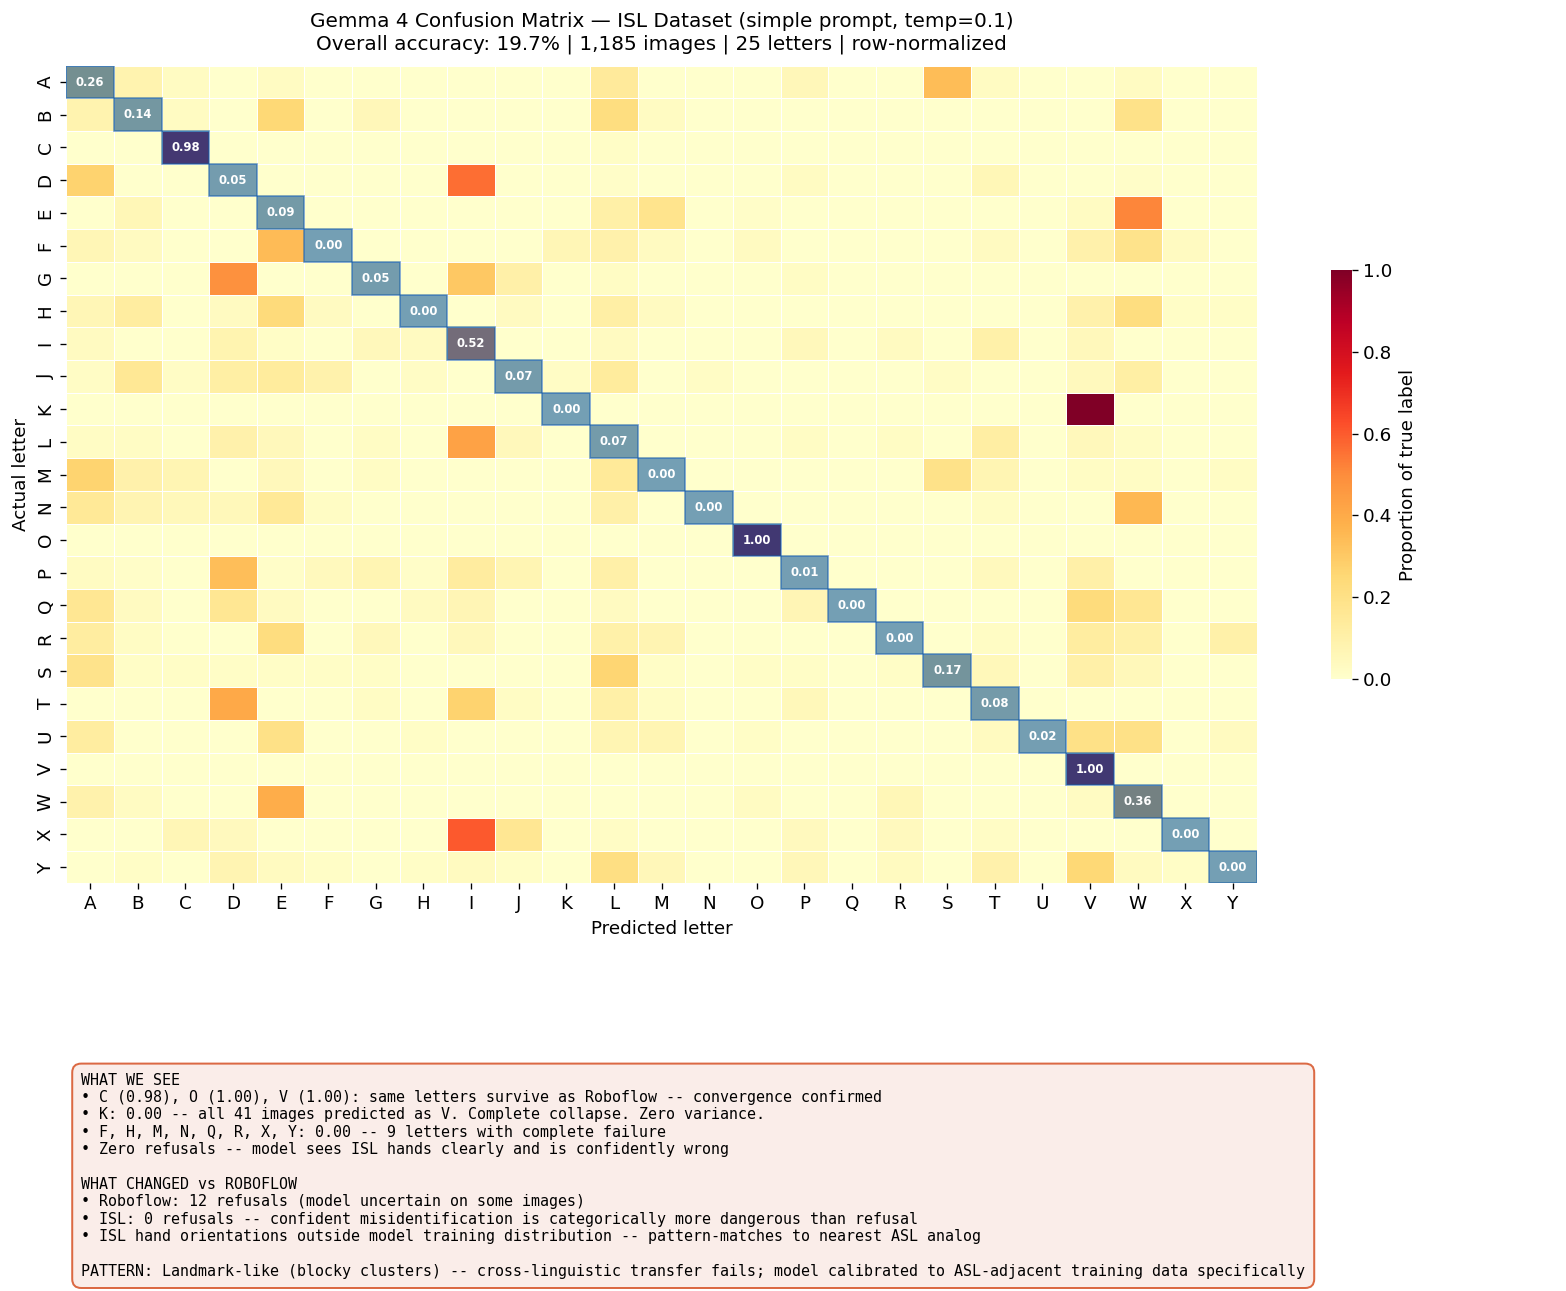

ISL overall: 19.7%
Convergence: Roboflow 20.5% vs ISL 19.7% -- ~1% gap across different sign languages
K: 0.00 on both datasets. 40/41 Roboflow and 41/41 ISL predicted as V.


In [ ]:
# --- GEMMA 4 CONFUSION MATRIX: ISL DATASET (row-normalized) ---

isl_matrix = np.array([
    [9,3,1,0,1,0,0,0,0,0,0,5,0,0,0,2,0,0,12,1,0,0,1,0,0],
    [3,5,1,0,9,0,2,0,0,0,0,8,1,0,0,0,0,0,0,0,0,0,7,0,0],
    [0,0,59,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [18,0,0,3,0,0,0,0,37,0,0,1,0,0,0,2,0,0,0,4,0,0,1,0,0],
    [0,4,0,0,6,0,0,0,0,0,0,7,12,0,1,0,0,0,0,0,0,2,34,0,0],
    [2,1,0,0,11,0,0,0,0,0,2,3,1,0,1,0,0,0,0,1,0,3,6,1,0],
    [0,0,0,19,0,0,2,0,12,4,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0],
    [4,8,0,2,15,2,0,0,0,2,0,7,2,0,0,0,0,0,0,0,0,6,14,1,1],
    [2,0,0,5,1,0,3,2,32,0,0,2,0,0,0,3,0,2,0,6,0,3,0,0,0],
    [1,7,1,5,6,4,0,1,0,3,1,6,0,1,0,0,0,0,1,0,0,2,5,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,41,0,0,0],
    [1,1,0,4,2,0,1,0,18,2,0,3,0,0,0,1,0,1,0,5,0,2,1,0,0],
    [11,4,3,0,2,0,1,0,0,0,0,6,0,0,0,0,0,0,8,3,0,1,1,0,1],
    [6,3,2,2,6,1,0,0,0,0,0,4,0,0,0,0,0,0,0,1,0,0,14,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,46,0,0,0,0,0,0,0,0,0,0],
    [2,1,0,23,1,3,5,1,9,5,0,7,0,0,0,1,0,0,0,3,0,7,0,0,0],
    [5,1,0,5,1,0,0,1,2,0,0,1,0,0,0,2,0,0,0,0,0,7,5,0,0],
    [5,1,0,0,9,0,2,0,2,0,0,4,3,0,0,0,0,0,0,1,0,5,4,0,4],
    [11,1,1,1,1,1,1,0,0,0,0,15,1,0,1,1,0,1,10,3,0,6,3,0,0],
    [0,0,0,15,0,0,1,0,10,1,0,4,1,0,0,2,0,0,0,3,0,0,0,0,0],
    [7,0,0,0,11,0,0,1,0,0,0,4,4,0,1,0,0,0,0,2,1,11,11,0,2],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,35,0,0,0],
    [3,1,0,0,13,0,0,0,0,0,0,0,0,0,1,0,0,2,0,0,0,1,12,0,0],
    [0,0,3,2,0,0,0,0,29,8,0,1,0,0,0,2,0,2,0,1,0,0,0,0,0],
    [0,1,0,4,2,1,0,1,2,1,0,11,3,0,0,3,0,2,0,5,0,13,2,1,0],
])

# Row-normalize: each row sums to 1.0
row_sums = isl_matrix.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1
norm_isl = isl_matrix / row_sums

isl_acc = isl_matrix.diagonal().sum() / isl_matrix.sum() * 100

fig = plt.figure(figsize=(16, 13))
gs = GridSpec(2, 1, height_ratios=[4, 1], hspace=0.35)
ax_cm = fig.add_subplot(gs[0])

sns.heatmap(norm_isl, annot=False, cmap='YlOrRd',
            xticklabels=LABELS, yticklabels=LABELS,
            linewidths=0.3, linecolor='white', ax=ax_cm,
            cbar_kws={'shrink': 0.5, 'label': 'Proportion of true label'},
            vmin=0, vmax=1.0)

for i in range(n):
    ax_cm.add_patch(plt.Rectangle((i, i), 1, 1, fill=True,
                    color='#185FA5', alpha=0.6, zorder=2))
    ax_cm.text(i+0.5, i+0.5, f'{norm_isl[i,i]:.2f}',
               ha='center', va='center', fontsize=7,
               color='white', fontweight='bold', zorder=3)

ax_cm.set_xlabel('Predicted letter', fontsize=11)
ax_cm.set_ylabel('Actual letter', fontsize=11)
ax_cm.set_title(
    f'Gemma 4 Confusion Matrix — ISL Dataset (simple prompt, temp=0.1)\n'
    f'Overall accuracy: {isl_acc:.1f}% | 1,185 images | 25 letters | row-normalized',
    fontsize=12, pad=10)

ax_call = fig.add_subplot(gs[1])
ax_call.axis('off')
callout = (
    'WHAT WE SEE\n'
    '\u2022 C (0.98), O (1.00), V (1.00): same letters survive as Roboflow -- convergence confirmed\n'
    '\u2022 K: 0.00 -- all 41 images predicted as V. Complete collapse. Zero variance.\n'
    '\u2022 F, H, M, N, Q, R, X, Y: 0.00 -- 9 letters with complete failure\n'
    '\u2022 Zero refusals -- model sees ISL hands clearly and is confidently wrong\n\n'
    'WHAT CHANGED vs ROBOFLOW\n'
    '\u2022 Roboflow: 12 refusals (model uncertain on some images)\n'
    '\u2022 ISL: 0 refusals -- confident misidentification is categorically more dangerous than refusal\n'
    '\u2022 ISL hand orientations outside model training distribution -- '
    'pattern-matches to nearest ASL analog\n\n'
    'PATTERN: Landmark-like (blocky clusters) -- '
    'cross-linguistic transfer fails; model calibrated to ASL-adjacent training data specifically'
)
ax_call.text(0.01, 0.95, callout, transform=ax_call.transAxes,
             fontsize=9, va='top', fontfamily='monospace',
             bbox=dict(boxstyle='round,pad=0.6', facecolor='#FAECE7',
                       edgecolor='#D85A30', linewidth=1.2, alpha=0.9))
plt.tight_layout()
plt.show()
print(f'ISL overall: {isl_acc:.1f}%')
print(f'Convergence: Roboflow {overall_acc:.1f}% vs ISL {isl_acc:.1f}% -- ~1% gap across different sign languages')
print(f'K: 0.00 on both datasets. 40/41 Roboflow and 41/41 ISL predicted as V.')


In [ ]:
import pandas as pd
df_roboflow_cm = pd.DataFrame(roboflow_matrix, index=LABELS, columns=LABELS)
df_roboflow_cm.to_csv('roboflow_confusion_matrix.csv')
print('Roboflow confusion matrix saved to roboflow_confusion_matrix.csv')

Roboflow confusion matrix saved to roboflow_confusion_matrix.csv


In [ ]:
import pandas as pd
df_isl_cm = pd.DataFrame(isl_matrix, index=LABELS, columns=LABELS)
df_isl_cm.to_csv('isl_confusion_matrix.csv')
print('ISL confusion matrix saved to isl_confusion_matrix.csv')

ISL confusion matrix saved to isl_confusion_matrix.csv


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Ted and I say thanks for reading and we will be updating this shortly
![Ted](https://raw.githubusercontent.com/phinnphace/asl-sovereign/main/ted.jpg)
